# Fase 1: Preelaborazione dei Dati (Preprocessing)

In questo notebook vengono caricati i dati clinici originali del **Framingham Heart Study** per analizzarne la struttura, le tipologie di variabili, i valori mancanti e le eventuali incoerenze cliniche. Si procede con la correzione dei dati errati e il salvataggio del dataset pulito pre-imputazione e di quello completamente imputato.

In [1]:
# Importazione delle librerie fondamentali per l'analisi dei dati e la modellizzazione
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import sklearn

In [2]:
# Caricamento del dataset originale contenente i dati clinici e anamnestici
dati_framingham = pd.read_csv("../Dataset/Original/framingham_heart_study.csv")
# Visualizzazione delle prime 10 righe per comprendere la struttura dei dati
dati_framingham.head(10)

In [3]:
# Conteggio di quanti valori validi (non nulli) sono presenti per ciascuna variabile
dati_framingham.count()

In [4]:
# Controllo dei tipi di dato associati ad ogni colonna del dataset
dati_framingham.dtypes

In [5]:
# Verifica che il numero delle colonne coincida con il numero dei tipi di dato estratti
len(dati_framingham.columns) == len(dati_framingham.dtypes)

In [6]:
# Calcolo del numero totale di righe (pazienti) che hanno almeno un valore mancante
colonne_con_valori_mancanti = set()
righe_con_almeno_un_nan = dati_framingham.isna().any(axis=1).sum()
print(f"Numero di righe con almeno un valore NULL: {righe_con_almeno_un_nan}")

Numero di righe con almeno un valore NULL: 582


In [7]:
# Definizione delle colonne che contengono informazioni logiche/booleane o categoriali binarie
colonne_booleane = ["male", "currentSmoker", "prevalentStroke", "prevalentHyp", "diabetes", "TenYearCHD", "BPMeds"]

# Analisi dei valori unici e la presenza di dati mancanti per ciascuna variabile booleana
for colonna in colonne_booleane:
    print(f"\n--- Analisi Colonna Booleana: {colonna} ---")    
    valori_unici = dati_framingham[colonna].unique()
    print(f"Valori unici: {valori_unici}")    
    if dati_framingham[colonna].isna().any():
        print("⚠️ Attenzione: contiene valori mancanti (NaN)")
        colonne_con_valori_mancanti.add(colonna)
    else:
        print("✅ Nessun valore mancante")


--- Analisi Colonna Booleana: male ---
Valori unici: [1 0]
✅ Nessun valore mancante

--- Analisi Colonna Booleana: currentSmoker ---
Valori unici: [0 1]
✅ Nessun valore mancante

--- Analisi Colonna Booleana: prevalentStroke ---
Valori unici: [0 1]
✅ Nessun valore mancante

--- Analisi Colonna Booleana: prevalentHyp ---
Valori unici: [0 1]
✅ Nessun valore mancante

--- Analisi Colonna Booleana: diabetes ---
Valori unici: [0 1]
✅ Nessun valore mancante

--- Analisi Colonna Booleana: TenYearCHD ---
Valori unici: [0 1]
✅ Nessun valore mancante

--- Analisi Colonna Booleana: BPMeds ---
Valori unici: [ 0.  1. nan]
⚠️ Attenzione: contiene valori mancanti (NaN)


In [8]:
# Conversione delle colonne booleane al formato 'boolean' nativo di pandas per una corretta gestione
for colonna in colonne_booleane:
    valori_precedenti = dati_framingham[colonna].copy()
    dati_framingham[colonna] = dati_framingham[colonna].astype('boolean')    
    print(f"\n--- Conversione Colonna: {colonna} ---")
    confronto = pd.DataFrame({'Prima': valori_precedenti, 'Dopo': dati_framingham[colonna]})
    print(confronto.head(5))


--- Conversione Colonna: male ---
   Prima   Dopo
0      1   True
1      0  False
2      1   True
3      0  False
4      0  False

--- Conversione Colonna: currentSmoker ---
   Prima   Dopo
0      0  False
1      0  False
2      1   True
3      1   True
4      1   True

--- Conversione Colonna: prevalentStroke ---
   Prima   Dopo
0      0  False
1      0  False
2      0  False
3      0  False
4      0  False

--- Conversione Colonna: prevalentHyp ---
   Prima   Dopo
0      0  False
1      0  False
2      0  False
3      1   True
4      0  False

--- Conversione Colonna: diabetes ---
   Prima   Dopo
0      0  False
1      0  False
2      0  False
3      0  False
4      0  False

--- Conversione Colonna: TenYearCHD ---
   Prima   Dopo
0      0  False
1      0  False
2      0  False
3      1   True
4      0  False

--- Conversione Colonna: BPMeds ---
   Prima   Dopo
0    0.0  False
1    0.0  False
2    0.0  False
3    0.0  False
4    0.0  False


In [9]:
# Visualizzazione del tipo delle variabili aggiornato dopo la conversione
print("\n--- Tipi di Dati Aggiornati ---")
print(dati_framingham.dtypes)


--- Tipi di Dati Aggiornati ---
male               boolean
age                  int64
education          float64
currentSmoker      boolean
cigsPerDay         float64
BPMeds             boolean
prevalentStroke    boolean
prevalentHyp       boolean
diabetes           boolean
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD         boolean
dtype: object


In [10]:
# Identificazione delle colonne numeriche continue (per differenza con quelle booleane)
colonne_numeriche = []
for colonna in dati_framingham.columns:
    if colonna not in colonne_booleane:
        colonne_numeriche.append(colonna)
print(f"Colonne numeriche identificate: {colonne_numeriche}")

Colonne numeriche identificate: ['age', 'education', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']


In [11]:
# Analisi delle statistiche descrittive ed i valori estremi per ogni variabile numerica continua
for colonna in colonne_numeriche:
    print(f"\n--- Analisi Variabile: {colonna} ---")    
    valori_validi = dati_framingham[colonna].dropna().unique()
    print(f"Primi 10 valori unici: {valori_validi[:10]}")    
    
    if dati_framingham[colonna].isna().any():
        print("⚠️ Attenzione: contiene valori mancanti (NaN)")
        colonne_con_valori_mancanti.add(colonna)
    else:
        print("✅ Nessun valore mancante")

    valore_minimo = dati_framingham[colonna].min()
    valore_massimo = dati_framingham[colonna].max()
    valore_medio = dati_framingham[colonna].mean()
    print(f"Minimo: {valore_minimo} | Massimo: {valore_massimo} | Media: {valore_medio:.2f}")

    primo_quartile = dati_framingham[colonna].quantile(0.25)
    terzo_quartile = dati_framingham[colonna].quantile(0.75)
    print(f"1° Quartile (25° percentile): {primo_quartile} | 3° Quartile (75° percentile): {terzo_quartile}")

    valori_piu_bassi = dati_framingham[dati_framingham[colonna] < primo_quartile][colonna].sort_values(ascending=True).head(5)    
    valori_piu_alti = dati_framingham[dati_framingham[colonna] > terzo_quartile][colonna].sort_values(ascending=False).head(5)
    print(f"I 5 valori più bassi: {list(valori_piu_bassi)}")
    print(f"I 5 valori più alti: {list(valori_piu_alti)}")



--- Analisi Variabile: age ---
Primi 10 valori unici: [39 46 48 61 43 63 45 52 50 41]
✅ Nessun valore mancante
Minimo: 32 | Massimo: 70 | Media: 49.58
1° Quartile (25° percentile): 42.0 | 3° Quartile (75° percentile): 56.0
I 5 valori più bassi: [32, 33, 33, 33, 33]
I 5 valori più alti: [70, 70, 69, 69, 69]

--- Analisi Variabile: education ---
Primi 10 valori unici: [4. 2. 1. 3.]
⚠️ Attenzione: contiene valori mancanti (NaN)
Minimo: 1.0 | Massimo: 4.0 | Media: 1.98
1° Quartile (25° percentile): 1.0 | 3° Quartile (75° percentile): 3.0
I 5 valori più bassi: []
I 5 valori più alti: [4.0, 4.0, 4.0, 4.0, 4.0]

--- Analisi Variabile: cigsPerDay ---
Primi 10 valori unici: [ 0. 20. 30. 23. 15.  9. 10.  5. 35. 43.]
⚠️ Attenzione: contiene valori mancanti (NaN)
Minimo: 0.0 | Massimo: 70.0 | Media: 9.01
1° Quartile (25° percentile): 0.0 | 3° Quartile (75° percentile): 20.0
I 5 valori più bassi: []
I 5 valori più alti: [70.0, 60.0, 60.0, 60.0, 60.0]

--- Analisi Variabile: totChol ---
Primi 10 va

<string>:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
<string>:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
<string>:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
<string>:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
<string>:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
<string>:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
<string>:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
<string>:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
<string>:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


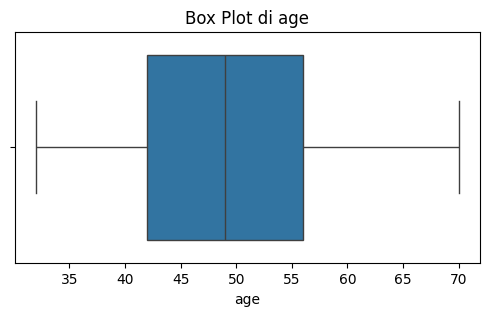

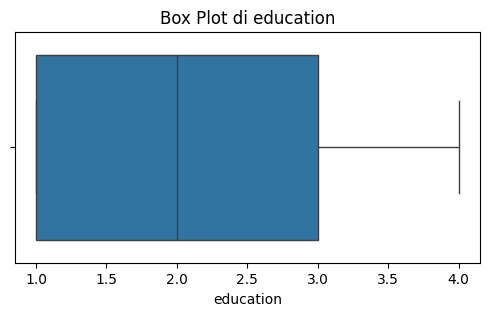

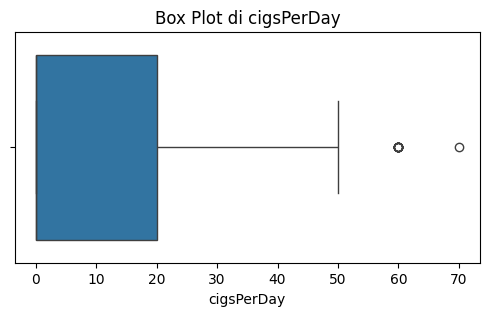

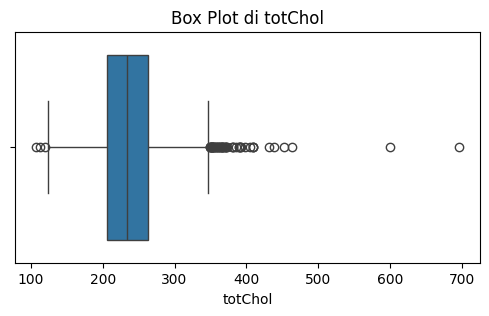

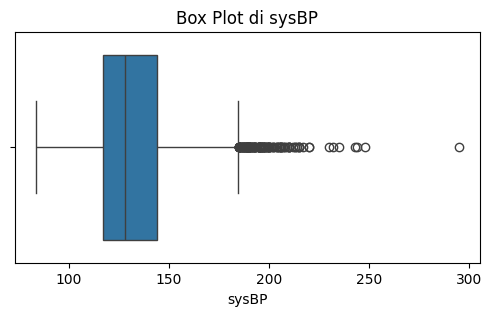

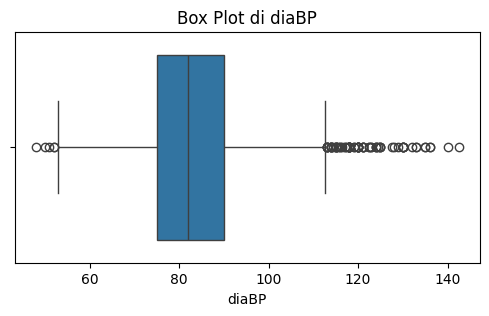

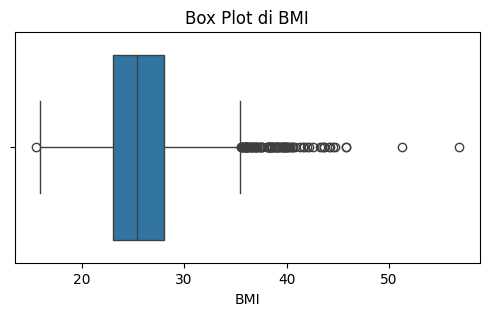

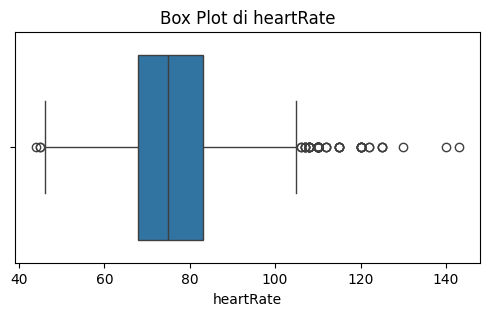

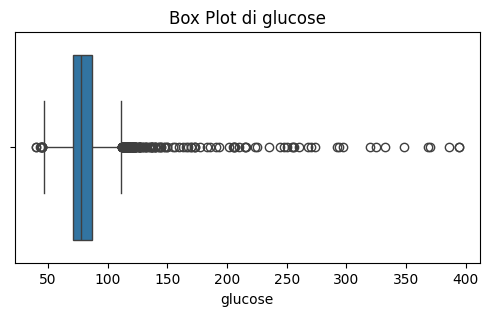

In [12]:
# Generazione dei grafici a scatola (Box Plot) per individuare visivamente la presenza di valori anomali (outlier)
for colonna in colonne_numeriche:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=dati_framingham[colonna])
    plt.title(f"Box Plot di {colonna}")
    plt.show()

In [13]:
# Verifica della coerenza clinica tra lo stato di fumatore ed il numero di sigarette consumate al giorno
non_fumatori_con_sigarette = dati_framingham[(dati_framingham['currentSmoker'] == 0) & (dati_framingham['cigsPerDay'] > 0)]
fumatori_senza_sigarette = dati_framingham[(dati_framingham['currentSmoker'] == 1) & ((dati_framingham['cigsPerDay'] == 0) | dati_framingham['cigsPerDay'].isna())]

print("=== VERIFICA INCOERENZE PRE-PULIZIA ===")
print(f"Pazienti non fumatori con sigarette al giorno > 0: {len(non_fumatori_con_sigarette)}")
print(f"Pazienti fumatori con sigarette al giorno a 0 o NaN: {len(fumatori_senza_sigarette)}")

# Correzione clinica:
# Se le sigarette al giorno sono maggiori di 0, il paziente è sicuramente fumatore
dati_framingham.loc[dati_framingham['cigsPerDay'] > 0, 'currentSmoker'] = True

# Se il paziente è classificato fumatore ma fuma 0 o ha valore mancante, impostiamo fumo a False e sigarette a 0
condizione_finto_fumatore = (dati_framingham['currentSmoker'] == 1) & ((dati_framingham['cigsPerDay'] == 0) | dati_framingham['cigsPerDay'].isna())
dati_framingham.loc[condizione_finto_fumatore, 'currentSmoker'] = False
dati_framingham.loc[condizione_finto_fumatore, 'cigsPerDay'] = 0

# Se non è fumatore ed ha valore sigarette mancante, impostiamo le sigarette a 0
dati_framingham.loc[(dati_framingham['currentSmoker'] == 0) & (dati_framingham['cigsPerDay'].isna()), 'cigsPerDay'] = 0

# Verifica post-pulizia
non_fumatori_con_sigarette_dopo = dati_framingham[(dati_framingham['currentSmoker'] == 0) & (dati_framingham['cigsPerDay'] > 0)]
fumatori_senza_sigarette_dopo = dati_framingham[(dati_framingham['currentSmoker'] == 1) & ((dati_framingham['cigsPerDay'] == 0) | dati_framingham['cigsPerDay'].isna())]

print("\n=== VERIFICA POST-PULIZIA ===")
print(f"Incoerenze residue A: {len(non_fumatori_con_sigarette_dopo)}") 
print(f"Incoerenze residue B: {len(fumatori_senza_sigarette_dopo)}")

=== VERIFICA INCOERENZE PRE-PULIZIA ===
Pazienti non fumatori con sigarette al giorno > 0: 0
Pazienti fumatori con sigarette al giorno a 0 o NaN: 29

=== VERIFICA POST-PULIZIA ===
Incoerenze residue A: 0
Incoerenze residue B: 0


In [14]:
# Verifica della coerenza dei valori pressori: la pressione sistolica deve essere maggiore della diastolica
pressioni_invertite = dati_framingham[dati_framingham['sysBP'] <= dati_framingham['diaBP']]
differenza_irrealistica = dati_framingham[(dati_framingham['sysBP'] > dati_framingham['diaBP']) & ((dati_framingham['sysBP'] - dati_framingham['diaBP']) < 10)]

print("=== VERIFICA ANOMALIE PRESSORIE PRE-PULIZIA ===")
print(f"Pazienti con pressioni invertite (sysBP <= diaBP): {len(pressioni_invertite)}")
print(f"Pazienti con differenza pressoria irrealistica (< 10 mmHg): {len(differenza_irrealistica)}")

# Se le pressioni sono invertite, scambiamo i valori
if len(pressioni_invertite) > 0:
    sys_temporanea = dati_framingham.loc[dati_framingham['sysBP'] <= dati_framingham['diaBP'], 'sysBP'].copy()    
    dati_framingham.loc[dati_framingham['sysBP'] <= dati_framingham['diaBP'], 'sysBP'] = dati_framingham.loc[dati_framingham['sysBP'] <= dati_framingham['diaBP'], 'diaBP']    
    dati_framingham.loc[dati_framingham['sysBP'] == dati_framingham['diaBP'], 'diaBP'] = sys_temporanea

# Se la differenza pressoria è inferiore a 10 mmHg, consideriamo i valori inaffidabili ed impostiamo a NaN
differenza_errata_condizione = (dati_framingham['sysBP'] - dati_framingham['diaBP']) < 10
dati_framingham.loc[differenza_errata_condizione, ['sysBP', 'diaBP']] = np.nan

# Verifica post-pulizia
pressioni_invertite_dopo = dati_framingham[dati_framingham['sysBP'] <= dati_framingham['diaBP']]
differenza_irrealistica_dopo = dati_framingham[(dati_framingham['sysBP'] > dati_framingham['diaBP']) & ((dati_framingham['sysBP'] - dati_framingham['diaBP']) < 10)]
pressioni_mancanti = dati_framingham['sysBP'].isna().sum()

print("\n=== VERIFICA POST-PULIZIA ===")
print(f"Incoerenze residue (Pressioni invertite): {len(pressioni_invertite_dopo)}") 
print(f"Incoerenze residue (Differenza < 10 mmHg): {len(differenza_irrealistica_dopo)}")
print(f"Dati pressori impostati a NaN (da imputare successivamente): {pressioni_mancanti}")

=== VERIFICA ANOMALIE PRESSORIE PRE-PULIZIA ===
Pazienti con pressioni invertite (sysBP <= diaBP): 0
Pazienti con differenza pressoria irrealistica (< 10 mmHg): 0

=== VERIFICA POST-PULIZIA ===
Incoerenze residue (Pressioni invertite): 0
Incoerenze residue (Differenza < 10 mmHg): 0
Dati pressori impostati a NaN (da imputare successivamente): 0


In [15]:
# Verifica della presenza di pazienti che assumono farmaci antiipertensivi (BPMeds) ma non considerati ipertesi (prevalentHyp)
farmaci_no_ipertensione = dati_framingham[(dati_framingham['BPMeds'] == 1) & (dati_framingham['prevalentHyp'] == 0)]

print("=== VERIFICA FARMACI VS IPERTENSIONE (PRE-PULIZIA) ===")
print(f"Pazienti con farmaci ma non considerati ipertesi: {len(farmaci_no_ipertensione)}")

# Se assumono farmaci per la pressione alta, devono essere considerati ipertesi
dati_framingham.loc[dati_framingham['BPMeds'] == 1, 'prevalentHyp'] = True

farmaci_no_ipertensione_dopo = dati_framingham[(dati_framingham['BPMeds'] == 1) & (dati_framingham['prevalentHyp'] == 0)]
print("\n=== POST-PULIZIA ===")
print(f"Incoerenze residue: {len(farmaci_no_ipertensione_dopo)}")

=== VERIFICA FARMACI VS IPERTENSIONE (PRE-PULIZIA) ===
Pazienti con farmaci ma non considerati ipertesi: 0

=== POST-PULIZIA ===
Incoerenze residue: 0


In [16]:
# Conteggio delle righe incomplete prima di applicare i filtri di consistenza
righe_con_nan_prima = dati_framingham.isna().any(axis=1).sum()
print(f"Numero di righe con almeno un valore NULL prima dei filtri: {righe_con_nan_prima}")

# Eliminazione delle righe che hanno più di 2 valori mancanti complessivi
nan_per_riga = dati_framingham.isna().sum(axis=1)
righe_da_eliminare = (nan_per_riga > 2).sum()
print(f"Numero di righe con più di 2 valori NULL eliminate: {righe_da_eliminare}")
dati_framingham = dati_framingham[nan_per_riga <= 2].copy()

# Eliminazione delle righe dove la variabile target 'TenYearCHD' è mancante
target_mancanti = dati_framingham['TenYearCHD'].isna().sum()
print(f"Pazienti con valore NULL nel target 'TenYearCHD' eliminati: {target_mancanti}")
dati_framingham = dati_framingham.dropna(subset=['TenYearCHD']).copy()

Numero di righe con almeno un valore NULL prima dei filtri: 559
Numero di righe con più di 2 valori NULL eliminate: 2
Pazienti con valore NULL nel target 'TenYearCHD' eliminati: 0


In [17]:
# Verifichiamo la percentuale di righe incomplete rimaste ed esportiamo il dataset pre-imputazione
percentuale_incomplete = (dati_framingham.isna().any(axis=1).sum() / dati_framingham.shape[0]) * 100
print(f"Percentuale righe incomplete residue nel dataset: {percentuale_incomplete:.2f}%")

# Salvataggio del dataset pre-imputazione (fondamentale per lo splitting pulito)
dati_framingham.to_csv('../Dataset/Clean/framingham_clean_pre_imputation.csv', index=False)
print("Dataset pre-imputazione salvato con successo in '../Dataset/Clean/framingham_clean_pre_imputation.csv'")

Percentuale righe incomplete residue nel dataset: 13.14%
Dataset pre-imputazione salvato con successo in '../Dataset/Clean/framingham_clean_pre_imputation.csv'


In [18]:
# Per la visualizzazione globale, eseguiamo l'imputazione KNN sull'intero dataset stratificando per sesso
knn_imputer = sklearn.impute.KNNImputer(n_neighbors=5)
frazioni_imputate = []

for sesso, sotto_gruppo in dati_framingham.groupby('male'):
    if len(sotto_gruppo) > 0:
        print(f"Imputazione per Sesso: {sesso} | Dimensione: {len(sotto_gruppo)} righe")
        
        # Esclusione temporanea di la variabile target per evitare target leakage
        X_temporaneo = sotto_gruppo.drop(columns=['TenYearCHD'])
        X_imputato_temp = pd.DataFrame(
            knn_imputer.fit_transform(X_temporaneo), 
            columns=X_temporaneo.columns, 
            index=sotto_gruppo.index
        )
        
        # Reinserimento della colonna target ed ordiniamo le colonne
        X_imputato_temp['TenYearCHD'] = sotto_gruppo['TenYearCHD']
        X_imputato_temp = X_imputato_temp[dati_framingham.columns]
        frazioni_imputate.append(X_imputato_temp)

dati_imputati_globali = pd.concat(frazioni_imputate).sort_index()
print(f"\n✅ Imputazione completata! NaN residui: {dati_imputati_globali.isna().sum().sum()}")

Imputazione per Sesso: False | Dimensione: 2418 righe
Imputazione per Sesso: True | Dimensione: 1820 righe

✅ Imputazione completata! NaN residui: 0


In [19]:
# Arrotondamento ad intero le variabili discrete per coerenza clinica
dati_imputati_globali = dati_imputati_globali.astype({'education': 'int64', 'cigsPerDay': 'int64'})
print(dati_imputati_globali[['cigsPerDay', 'education']].dtypes)

cigsPerDay    int64
education     int64
dtype: object


In [20]:
# Salvataggio del dataset imputato per la visualizzazione dei dati
dati_imputati_globali.to_csv('../Dataset/Clean/framingham_clean.csv', index=False)
print("Dataset completo e imputato salvato con successo in '../Dataset/Clean/framingham_clean.csv'!")

Dataset completo e imputato salvato con successo in '../Dataset/Clean/framingham_clean.csv'!
